In [1]:
import glob
import itertools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

In [2]:
results_dir = '../rnn_results/final/'

# kernel_taus            = [1.9]
# read_delays            = [0.0, 0.1, 1.9]
# autocorrs              = [0.9]
# zero_integration_flags = [True, False]
# etas                   = [0.1, 0.25, 0.5]

all_dirs = glob.glob(results_dir + 'autocorr*_ktau*_zeroint*_delay*_normal_eta*')

found_autocorrs = {f.split('autocorr')[-1].split('_')[0] for f in all_dirs}
found_ktaus     = {f.split('ktau')[-1].split('_')[0]     for f in all_dirs}
found_zeroint   = {f.split('zeroint')[-1].split('_')[0]  for f in all_dirs}
found_delays    = {f.split('delay')[-1].split('_')[0]    for f in all_dirs}
found_etas      = {f.split('eta')[-1].split('_')[0]      for f in all_dirs}

In [3]:
separated_dirs = {}

for autocorr, ktau, zeroint, delay, eta in itertools.product(
        found_autocorrs, found_ktaus, found_zeroint, found_delays, found_etas):

    key = ('autocorr' + autocorr,
           'ktau'     + ktau,
           'zeroint'  + zeroint,
           'delay'    + delay,
           'eta'      + eta)

    separated_dirs[key] = [
        f for f in all_dirs
        if (f'autocorr{autocorr}_' in f
            and f'ktau{ktau}_'       in f
            and f'zeroint{zeroint}_' in f
            and f'delay{delay}_'     in f
            and f'eta{eta}_'         in f)
    ]

# Load weights for every condition combination

weights = {'rec': {}, 'input': {}, 'output': {}, 'tau': {}}

for autocorr, ktau, zeroint, delay, eta in itertools.product(
        found_autocorrs, found_ktaus, found_zeroint, found_delays, found_etas):

    key = ('autocorr' + autocorr,
           'ktau'     + ktau,
           'zeroint'  + zeroint,
           'delay'    + delay,
           'eta'      + eta)

    filepaths = separated_dirs[key]
    for wk in weights:
        weights[wk][key] = []

    for filepath in filepaths:
        rnn = torch.load(filepath + '/best_model.pth')
        weights['rec'][key].append(rnn['hh.weight'])
        weights['input'][key].append(rnn['ih.weight'])
        weights['output'][key].append(rnn['ho.weight'])
        weights['tau'][key].append(rnn['taus'])

    for wk in weights:
        weights[wk][key] = np.array(weights[wk][key])

In [4]:
def _frob_normalize(hh):
    # hh: (n_fits, N, N)
    scales = np.linalg.norm(hh, axis=(1,2), keepdims=True)
    hh_norm = hh / scales
    return hh_norm

def bin_and_average_rec_weights(weights, key, n_bins=20):
    hh_all = weights['rec'][key]
    hh_norm = _frob_normalize(hh_all)
    taus_all = weights['tau'][key]

    n_seeds = hh_all.shape[0]
    out = np.zeros((n_seeds, n_bins, n_bins))

    for f in range(n_seeds):
        hh = hh_norm[f]
        taus = taus_all[f]

        # quantile binning (frequency-based)
        edges = np.quantile(taus, np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)

        # assign bins
        bin_idx = np.digitize(taus, edges[1:-1])

        # preprocess weights
        hh_proc = np.abs(hh)
        np.fill_diagonal(hh_proc, np.nan)

        for i in range(n_bins):
            src = np.where(bin_idx == i)[0]
            if len(src) == 0:
                continue

            for j in range(n_bins):
                tgt = np.where(bin_idx == j)[0]
                if len(tgt) == 0:
                    continue

                out[f, j, i] = np.nanmean(
                    hh_proc[np.ix_(tgt, src)]
                )

    final_mat = np.nanmean(out, axis=0)

    return final_mat, edges

('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', 'eta0.1')


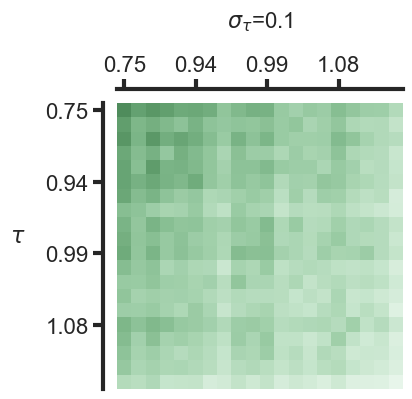

('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', 'eta0.25')


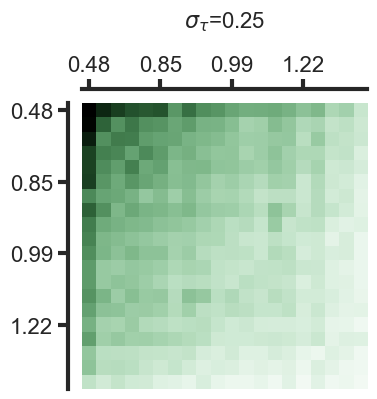

('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', 'eta0.5')


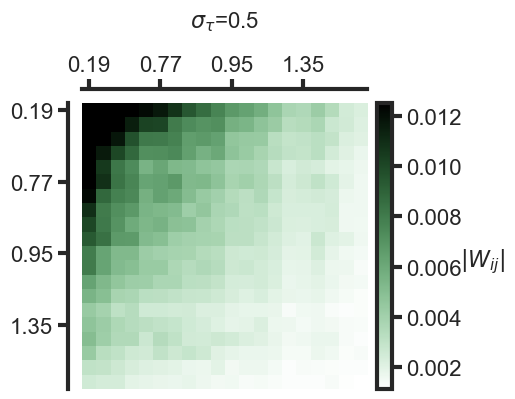

In [10]:
sns.set_theme(
    style="ticks",
    rc={
        "axes.spines.right": True,
        "axes.spines.top": True,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

etas = [0.1, 0.25, 0.5]
min_vals = []
max_vals = []

for idx, eta, in enumerate(etas):
    key = ('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', f'eta{eta}')
    final_mat, _ = bin_and_average_rec_weights(weights, key)
    min_vals.append(final_mat.min())
    max_vals.append(final_mat.max())

from mpl_toolkits.axes_grid1 import make_axes_locatable

for idx, eta in enumerate(etas):
    key = ('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', f'eta{eta}')
    print(key)

    final_mat, taus = bin_and_average_rec_weights(weights, key)

    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_title(rf'$\sigma_\tau$={eta}', pad=20)

    
    im = ax.imshow(
        final_mat,
        cmap=sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, reverse=False, as_cmap=True),
        interpolation='nearest',
        vmin=np.min(min_vals),
        vmax= 0.0125 #np.max(max_vals)
    )

    # --- spine styling ---
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(bottom=False, labelbottom=False)
    
    if idx==0:
        ax.set_ylabel(r'$\tau$', rotation=0, labelpad=20)

    ticks = [0, 5, 10, 15]

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    labels = [f"{taus[i]:.2f}" for i in ticks]

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # --- create a consistent colorbar axis ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)

    if idx == len(etas) - 1:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(r'$|W_{ij}|$', rotation=0, labelpad=15)
    else:
        # keep space but hide it
        cax.set_visible(False)

    plt.show()

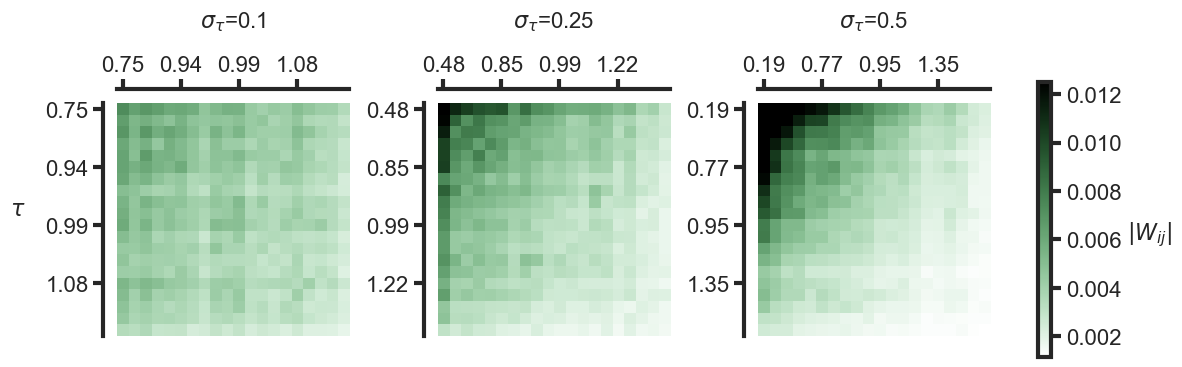

In [27]:
etas = [0.1, 0.25, 0.5]

# --- get global color scale ---
min_vals, max_vals = [], []
for eta in etas:
    key = ('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', f'eta{eta}')
    final_mat, _ = bin_and_average_rec_weights(weights, key)
    min_vals.append(final_mat.min())
    max_vals.append(final_mat.max())

vmin = np.min(min_vals)
vmax = np.max(max_vals)
vmax = 0.0125

# --- create subplots ---
fig, axes = plt.subplots(1, len(etas), figsize=(12,4))

# --- colormap ---
cmap = sns.cubehelix_palette(start=2, rot=0, dark=0, light=1,
                             reverse=False, as_cmap=True)

for idx, (ax, eta) in enumerate(zip(axes, etas)):
    key = ('autocorr0.9', 'ktau1.9', 'zerointFalse', 'delay1.9', f'eta{eta}')
    final_mat, taus = bin_and_average_rec_weights(weights, key)

    im = ax.imshow(
        final_mat,
        cmap=cmap,
        interpolation='nearest',
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(rf'$\sigma_\tau$={eta}', pad=20)

    # --- spine styling ---
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_position(('outward', 10))
    ax.spines['left'].set_position(('outward', 10))

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(bottom=False, labelbottom=False)

    # --- ticks + tau labels ---
    ticks = [0, 5, 10, 15]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    labels = [f"{taus[i]:.2f}" for i in ticks]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # only leftmost gets y-label
    if idx == 0:
        ax.set_ylabel(r'$\tau$', rotation=0, labelpad=20)

# leave space for colorbar before adding it
plt.tight_layout(rect=[0, 0, 0.92, 1])

# shared colorbar with explicit padding
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.05)
cbar.set_label(r'$|W_{ij}|$', rotation=0, labelpad=20)